# Sample a city and build a Street View H5 store

Given a city name (or a custom boundary file), this notebook:

1. Loads the city boundary.
2. Downloads / loads the OSM drive road graph.
3. Samples points along road edges at a fixed metric spacing.
4. Runs the **free** Street View metadata endpoint to find which points have a panorama.
5. Downloads four-heading JPEGs per pano (this is the **paid** step).
6. Packs everything into a per-city H5 with the same schema as the existing Manchester store, plus extra fields (`pano_id`, `city`, `round_id`, `status`, `copyright`, `pano_lat/lon`, `sampled_lat/lon`).

**Resumability:** every stage is cached on disk. Interrupt and rerun any cell — the script picks up exactly where it stopped, and no API calls are repeated unnecessarily.

**Add more samples later:** rerun the sampling cell with a smaller `spacing_m` (denser) for the same city. New candidates are deduped against existing points (6dp lat/lon) and given fresh `point_id`s; existing data is untouched.

**Multiple cities:** each city gets its own folder under `data/<city_slug>/`. Use `merge_city_h5s` to combine them on demand.

**API key:** script expects a file called `google_maps_api_key.txt` in the same folder as this notebook,

In [2]:
import importlib
import paths as paths_mod
import city_pipeline as cp
importlib.reload(paths_mod)
importlib.reload(cp)
from paths import CityPaths, get_api_key

import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


## 1. Configure the run

- `CITY_NAME` is what OSM's geocoder will look up *unless* `POLYGON_PATH` is set, in which case the polygon file is used (and `CITY_NAME` is just used for the slug and for the H5 `city` field).
- `SPACING_M` controls how dense the sample is. 50 m gives a Manchester-scale dataset; try 200 m for a first pass on a new city.
- `MAX_POINTS` is a safety cap on how many images get downloaded in one go — useful for spot-checking on a new city before committing to a full run.
- `DEDUPE_TWO_WAY` (default `True`) samples each physical road once. A two-way street is two directed edges in the graph; sampling both roughly doubles the points and cost on most urban roads with no extra imagery. Set `False` only to reproduce/compare the old every-directed-edge behaviour. See section 3 for the full explanation.

In [19]:
CITY_NAME = "Bradford, UK"
POLYGON_PATH = None  # or e.g. "my_custom_boundary.geojson"
#SPACING_M = 50.0
SPACING_M = 150.0  # Big, for testing

MAX_POINTS = None       # cap on points to send to image download; None = no cap
DEDUPE_TWO_WAY = True   # sample each road once (True) vs every directed edge (False)

paths = CityPaths.for_city(CITY_NAME)
paths.ensure_dirs()
print("City slug:", paths.slug)
print("Data root:", paths.root)

City slug: bradford_uk
Data root: /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk


In [20]:
# More info about the data paths for this city
print(paths)

CityPaths(slug='bradford_uk')
  root : /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk
  boundary_geojson ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/boundary.geojson
  road_graph       ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/road_graph.graphml
  points_parquet   ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/points.parquet
  samples_manifest ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/samples_manifest.parquet
  pano_metadata    ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/pano_metadata.parquet
  attempted        ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data/bradford_uk/attempted.parquet
  images_dir       ✓  /Users/geonsm/gp/INTEGRATE-Embeddings-Deprivation/mult_city_data_store/data

## 2. Boundary and road graph

Both are cached. The first run pulls from OSM (slow); subsequent runs load from disk.

Graph: 19695 nodes, 44363 edges.


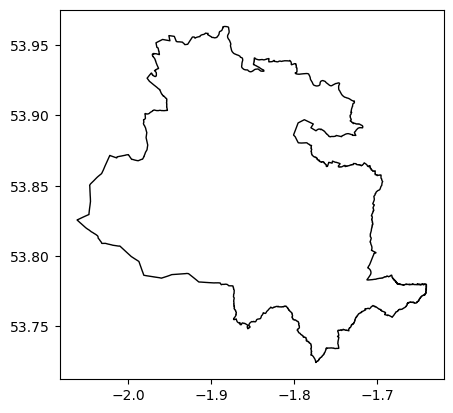

In [21]:
boundary = cp.load_boundary(CITY_NAME, polygon_path=POLYGON_PATH)
graph = cp.build_road_graph(boundary, paths)
print(f"Graph: {len(graph.nodes)} nodes, {len(graph.edges)} edges.")
boundary.plot(facecolor="none", edgecolor="black");

## 3. Sample points along edges (round 1, or N+1)

This section decides **where** in the city you end up with imagery and how dense
that coverage is, so it's worth understanding in detail. The strategy lives in
`cp.sample_points_along_edges` (placement) and `cp.register_sampling_round`
(merging into the master table).

### What gets sampled
- Points are drawn from the **OSM `drive` road network** built in step 2 — i.e.
  roads a car can drive on. Footpaths, cycleways, pedestrianised streets and the
  service/track ways excluded by OSMnx's `drive` filter are **not** sampled. To
  cover those, change `network_type` in `cp.build_road_graph`.
- The graph is built with `simplify=True`, so chains of degree-2 nodes are
  collapsed into single edges whose geometry still traces the real road curve.
  Sampling walks that curved geometry, not straight node-to-node lines.

### How points are placed along each edge
For every edge of length `L` metres, points are placed at the along-edge
distances

`spacing/2, 3·spacing/2, 5·spacing/2, …`&nbsp;&nbsp;(`np.arange(spacing/2, L, spacing)`)

so consecutive points are exactly `SPACING_M` apart and the **first/last point
sits `spacing/2` from each endpoint**. Using half-spacing offsets (instead of
starting at the node) keeps samples away from junctions, so edges meeting at an
intersection don't stack points on top of each other there. An edge shorter than
`spacing/2` gets **no** point (tiny stubs are skipped). Distance is true metric
length (`ox.distance.add_edge_lengths`, geodesic metres) and each point is found
by interpolating along the edge's actual geometry at the matching fraction of
its length, so points follow bends in the road.

### `SPACING_M` — the density / cost knob
`SPACING_M` is the along-road gap in metres and the main coverage lever:
- **50 m** → Manchester-scale density (the existing store was built at this).
- **100–200 m** → sparser; good for a cheap first pass on a new city.
- Image count (and £ cost) scales roughly with *total road length ÷ spacing × 4
  headings*. Halving the spacing roughly doubles the points.

### Each physical road is sampled once (`DEDUPE_TWO_WAY=True`)
The drive graph is **directed**: a two-way street is stored as two edges
(`u→v` and `v→u`) whose geometry is an exact reverse of each other. Sampling
both would put ~twice as many points (and twice the image cost) on every two-way
road — which is most of an urban network — and would interleave the two offset
point sets into an irregular spacing. So by default the sampler **collapses each
edge and its reverse to a single road**: it canonicalises the edge's coordinate
sequence (rounded to ~1 cm) so a geometry and its reverse hash to the same key,
and skips the second time it sees that key. No imagery is lost by dropping a
direction — the four fixed compass headings (0/90/180/270°) capture the same
views either way. Genuinely separate roads (divided carriageways, parallel
streets) have *distinct*, not reversed-identical, geometry, so they are
correctly kept and sampled independently.

Set `DEDUPE_TWO_WAY = False` (config cell) to sample every directed edge
instead — the old behaviour, kept only for reproducing or comparing against it.

### Determinism and de-duplication
- Candidates are sorted by `(edge_u, edge_v, edge_key, edge_offset_m)` before
  anything else, so the **same graph + same spacing always yields the same
  points in the same order** — runs are reproducible.
- Within a single pass, points are de-duplicated on `(sampled_lat, sampled_lon)`
  rounded to **6 dp** (≈ 0.11 m), removing the rare exact collisions at
  junctions (the one-direction rule above already removes the systematic
  two-way duplicates).
- `cp.register_sampling_round` then de-duplicates the new candidates against
  everything already in `points.parquet` (again 6 dp lat/lon). Only genuinely
  new points are appended; they get fresh `point_id`s strictly greater than the
  current max and a new `round_id`. **Existing rows are never moved or
  renumbered.**

### Adding density later (round N+1)
Re-running this section with a **smaller** `SPACING_M` adds the in-between points
without disturbing what you already have: existing points are kept, and only the
new offsets that don't collide at 6 dp are appended under a new `round_id`. The
manifest cell below records each round's spacing and point count.

In [22]:
# Create a new sample of candidate points.
# This is in-memory only — nothing is written to the store yet. You can re-run
# this (e.g. with a different SPACING_M) as many times as you like; only the
# explicit "commit" cell further down appends to points.parquet.
candidates = cp.sample_points_along_edges(graph, spacing_m=SPACING_M, dedupe_two_way=DEDUPE_TWO_WAY)
print(f"{len(candidates)} candidate points sampled (not yet committed to the store).")
candidates.head()

Sampled 9826 points from 23037 roads. 15416 roads (66.9%) shorter than 75 m were skipped with no point (604.0 km of road unsampled).
9826 candidate points sampled (not yet committed to the store).


,edge_u,edge_v,edge_key,edge_offset_m,edge_length_m,geometry,sampled_lat,sampled_lon
0,10384724,1633054000,0,75.0,157.701020,POINT (-1.70546 53.80162),53.801616,-1.705456
1,10384786,1215353058,0,75.0,113.408177,POINT (-1.71857 53.79397),53.793968,-1.718569
2,10384884,1120243919,0,75.0,130.259986,POINT (-1.70859 53.80063),53.800634,-1.708592
3,10385004,21184500,0,75.0,170.507435,POINT (-1.71993 53.79762),53.797615,-1.719927
4,10385004,1215353068,0,75.0,93.767912,POINT (-1.71875 53.79725),53.797248,-1.718754


### Preview the sample *before* committing

This map shows what you'd get **if** you commit this sample, so you can sanity-check
coverage/density and decide whether to re-sample (change `SPACING_M` above and re-run)
before anything is written to disk. Four categories:

- **Orange — new this round (uncommitted):** freshly-sampled candidates that aren't
  already in the store. These are what the commit cell would append.
- **Green — existing, has images:** points from a previous round that already have at
  least one downloaded image.
- **Grey — existing, no images yet:** points sampled in a previous round but not yet
  downloaded (no successful image attempt logged). These are candidates for the next
  metadata/download pass.

On a first run for a city there are no existing points, so everything is orange.

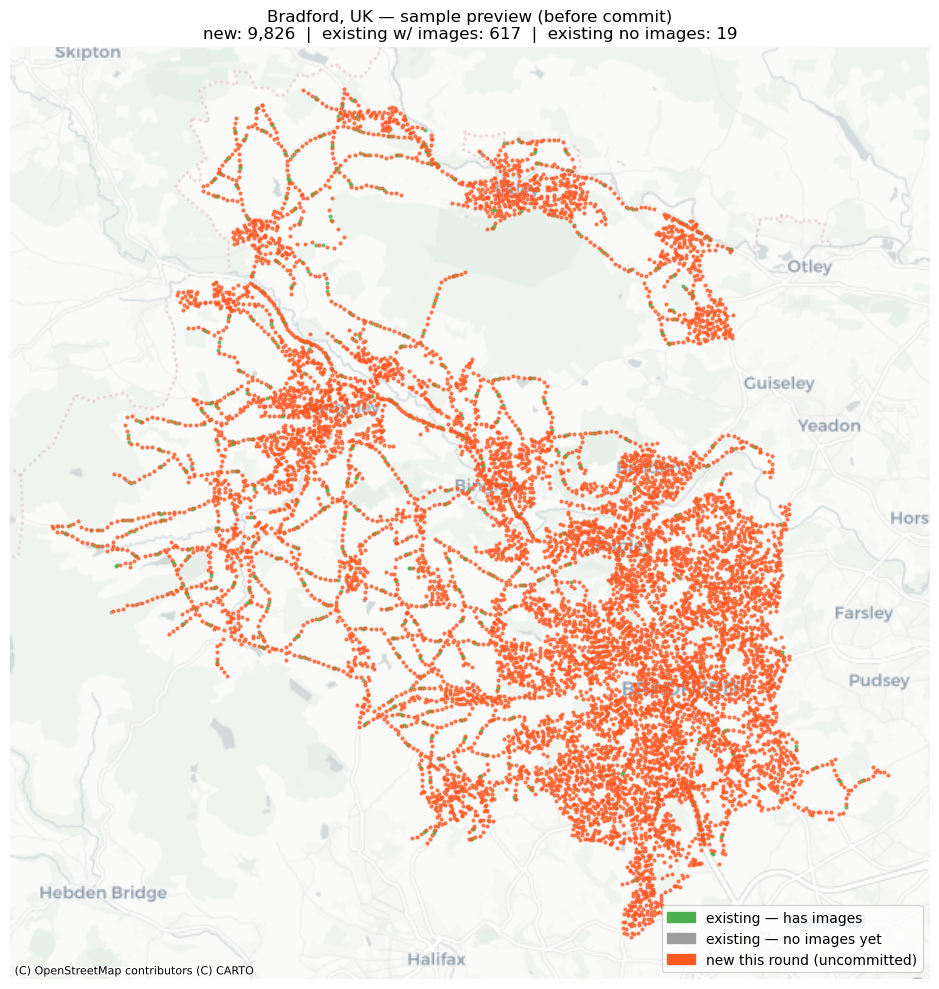

9,845 points awaiting download (19 existing without images + 9,826 new this round).


In [23]:
# Preview map — built from the in-memory `candidates` plus whatever is already in
# the store. Run BEFORE committing so you can decide whether to re-sample.

# Existing points already committed to the store (empty on a first run).
if paths.points_parquet.exists():
    existing = pd.read_parquet(paths.points_parquet)
else:
    existing = pd.DataFrame(columns=["point_id", "sampled_lat", "sampled_lon"])

# Which existing points already have at least one downloaded image?
# (a successful attempt logged in attempted.parquet)
if paths.attempted.exists():
    attempted = pd.read_parquet(paths.attempted)
    img_ids = set(attempted.loc[attempted["status"] == "ok", "point_id"].astype(int))
else:
    img_ids = set()

# Which freshly-sampled candidates are genuinely new? Mirrors the dedupe in
# register_sampling_round: (sampled_lat, sampled_lon) at 6 dp.
key_existing = set(zip(existing["sampled_lat"], existing["sampled_lon"]))
cand_new = candidates[~candidates.apply(
    lambda r: (r["sampled_lat"], r["sampled_lon"]) in key_existing, axis=1
)].copy()
cand_new["_cat"] = "new"

# Tag existing points by whether they already have imagery.
existing = existing.copy()
if len(existing):
    existing["_cat"] = np.where(
        existing["point_id"].astype(int).isin(img_ids),
        "existing_with_images",
        "existing_no_images",
    )

# Combine into one frame for plotting.
cols = ["sampled_lat", "sampled_lon", "_cat"]
frames = [df[cols] for df in (existing, cand_new) if len(df)]
plot_df = pd.concat(frames, ignore_index=True)

gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["sampled_lon"], plot_df["sampled_lat"]),
    crs=4326,
).to_crs(3857)

# Draw existing first, new on top so the uncommitted points stand out.
draw_order = ["existing_with_images", "existing_no_images", "new"]
colours = {
    "existing_with_images": "#4CAF50",  # green  — already has imagery
    "existing_no_images":   "#9E9E9E",  # grey   — sampled before, no images yet
    "new":                  "#FF5722",  # orange — sampled now, not yet committed
}
labels = {
    "existing_with_images": "existing — has images",
    "existing_no_images":   "existing — no images yet",
    "new":                  "new this round (uncommitted)",
}

fig, ax = plt.subplots(figsize=(10, 10))
for cat in draw_order:
    grp = gdf[gdf["_cat"] == cat]
    if len(grp):
        grp.plot(ax=ax, color=colours[cat], markersize=4, alpha=0.7)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom="auto")
ax.set_axis_off()

counts = gdf["_cat"].value_counts()
n_new   = int(counts.get("new", 0))
n_img   = int(counts.get("existing_with_images", 0))
n_noimg = int(counts.get("existing_no_images", 0))
ax.set_title(
    f"{CITY_NAME} — sample preview (before commit)\n"
    f"new: {n_new:,}  |  existing w/ images: {n_img:,}  |  existing no images: {n_noimg:,}",
    fontsize=12,
)
ax.legend(
    handles=[mpatches.Patch(color=colours[c], label=labels[c]) for c in draw_order],
    loc="lower right",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# Points still needing imagery if you commit this sample: the existing grey
# points plus the new ones (which start with no images). This is what the
# download pass (only_missing=True) will fetch.
print(
  f"{n_noimg + n_new:,} points awaiting download "
  f"({n_noimg:,} existing without images + {n_new:,} new this round)."
)


### Commit the new points to the store

Happy with the preview above? Run the next cell to append the new (orange) points to
the master point table (`points.parquet`) and record the round in the manifest. This is
the only step here that writes to disk. It's append-only and deduped, so re-running it is
safe: a second run with the same spacing simply reports "No new points".

In [24]:
# Commit: append the genuinely-new candidates to points.parquet and log the round.
new_rows = cp.register_sampling_round(candidates, paths, spacing_m=SPACING_M)
new_rows.head()

Round 3: added 9826 new points (ids 636..10461); 0 dedupe-skipped.


,point_id,round_id,sampled_lat,sampled_lon,edge_u,edge_v,edge_key,edge_offset_m,edge_length_m
0,636,3,53.801616,-1.705456,10384724,1633054000,0,75.0,157.701020
1,637,3,53.793968,-1.718569,10384786,1215353058,0,75.0,113.408177
2,638,3,53.800634,-1.708592,10384884,1120243919,0,75.0,130.259986
3,639,3,53.797615,-1.719927,10385004,21184500,0,75.0,170.507435
4,640,3,53.797248,-1.718754,10385004,1215353068,0,75.0,93.767912


In [25]:
# Inspect the manifest of all sampling rounds done so far for this city.
pd.read_parquet(paths.samples_manifest)

,round_id,timestamp,spacing_m,n_new_points,id_lo,id_hi
0,1,2026-06-01T17:28:07+00:00,1000.0,298,0,297
1,2,2026-06-02T06:56:19+00:00,900.0,338,298,635
2,3,2026-06-03T12:12:33+00:00,150.0,9826,636,10461


## 4. Metadata pass (free)

This calls Google's Street View metadata endpoint, which is **free**. It tells us which points have a panorama, what `pano_id` they snap to, and what date the imagery is from. Pass `only_missing=False` to refresh.

The api_key is stored locally but not in the github repo.

In [26]:
with open('google_maps_api_key.txt', 'r') as f:
    api_key = f.readline().strip()

if not api_key:
    raise ValueError("API key file was empty or missing")
else:
    print(f"API key loaded: {api_key[:8]}…{api_key[-4:]}  ({len(api_key)} chars)")

meta = cp.fetch_metadata_for_points(paths, api_key, only_missing=True)
counts = meta["status"].value_counts()

# Error checking and advice (often to do with API problems)

n_denied = counts.get("REQUEST_DENIED", 0)
n_total  = len(meta)
if n_denied == n_total:
    raise RuntimeError(
        f"ALL {n_denied} points returned REQUEST_DENIED — the API key is likely misconfigured.\n"
        "Common causes:\n"
        "  1. Street View Static API not enabled — Cloud Console → APIs & Services\n"
        "     → Library → search 'Street View Static API' → Enable.\n"
        "  2. Billing not active on the Cloud project.\n"
        "  3. Key has IP/referrer restrictions blocking server-side requests.\n"
        "Quick test: paste this URL into a browser and read the JSON error_message:\n"
        f"  https://maps.googleapis.com/maps/api/streetview/metadata?location=53.8,-1.7&key=<your_key>"
    )
elif n_denied > 0:
    print(
        f"⚠  {n_denied}/{n_total} points returned REQUEST_DENIED (the rest succeeded).\n"
        "This is usually a transient rate-limit or a small number of restricted coordinates.\n"
        "Re-run with only_missing=True to retry just the denied points."
    )

counts


API key loaded: AIzaSyBu…afVA  (39 chars)


metadata:   0%|          | 0/9826 [00:00<?, ?it/s]

Metadata: 10265/10462 points have a pano (status=OK).


status
OK               10265
ZERO_RESULTS       193
UNKNOWN_ERROR        4
Name: count, dtype: int64

## 5. Image download (paid)

The first call below is a **dry run**: it prints how many image requests would be made and the estimated USD cost, but downloads nothing. Set `dry_run=False` in the next cell when you're ready to spend the money.

### Spending guardrails
- **Set a daily quota cap in the Google Cloud console** — the real hard stop, applied by Google itself. Cap the *paid image* endpoint, **not** metadata (metadata is the free step 4). See the setup steps below. Do this once and you never have to think about it again.
- **`MAX_POINTS`** (config cell) caps how many points reach this paid step in a given run.
- **Resumability** — already-downloaded images are skipped, so reruns don't re-pay.

In [27]:
_ = cp.download_images(paths, api_key, max_points=MAX_POINTS, dry_run=True)

Eligible points: 10265; image requests to make: 38592; estimated cost: $270.14 (at $7.0/1000).
dry_run=True — no images downloaded. Set dry_run=False to proceed.


In [ ]:
# Set dry_run=False to actually download. Safe to interrupt and rerun.
attempted = cp.download_images(paths, api_key, max_points=MAX_POINTS, dry_run=False)
attempted["status"].value_counts()

## 6. Build the H5

Reads the master point table + metadata + on-disk JPEGs and writes the per-city H5. Safe to rerun at any time — it's a full rebuild from disk state, so it always reflects whatever's been downloaded so far. Points that were attempted but have no image (no-pano or error) are kept as rows with `images_present=False`.

In [ ]:
h5_path = cp.build_h5(paths, city_name=CITY_NAME)
cp.show_h5_summary(h5_path)

## 7. Sanity check — render a row's images

In [ ]:
import io
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

with h5py.File(h5_path, "r") as f:
    # Find the first row that has all four images present.
    present = f["images_present"][:]
    candidates = np.where(present.all(axis=1))[0]
    if len(candidates) == 0:
        candidates = np.where(present.any(axis=1))[0]
    row_idx = int(candidates[0])
    headings = list(np.asarray(f.attrs["headings"]))
    fig, axes = plt.subplots(1, len(headings), figsize=(4 * len(headings), 4))
    for j, ax in enumerate(axes):
        if not f["images_present"][row_idx, j]:
            ax.set_title(f"{headings[j]}\u00b0 (missing)")
            ax.axis("off")
            continue
        img = Image.open(io.BytesIO(f["images_jpeg"][row_idx, j].tobytes())).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{headings[j]}\u00b0")
        ax.axis("off")
    pid = int(f["point_id"][row_idx])
    plt.suptitle(f"point_id={pid}  pano={f['pano_id'][row_idx].decode('utf-8', 'ignore')}")
    plt.tight_layout()
    plt.show()

## 8. Optional: merge multiple cities into one combined H5

In [ ]:
# Example — uncomment to use.
# from pathlib import Path
# combined = cp.merge_city_h5s(
#     [CityPaths.for_city(n).h5 for n in ["Leeds, UK", "Sheffield, UK"]],
#     out_path=Path("data/combined_street_data.h5"),
# )